# Face Transformer - Rethinking model incorporating EfficientNet into ViT


## Visualization of Data


### Code to show multiple images


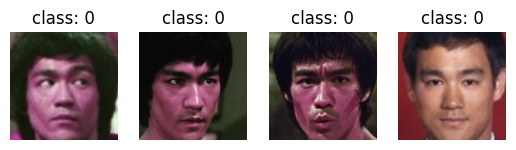

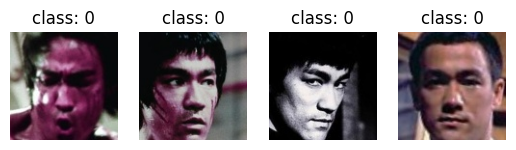

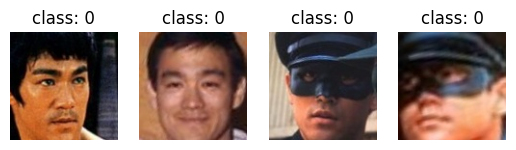

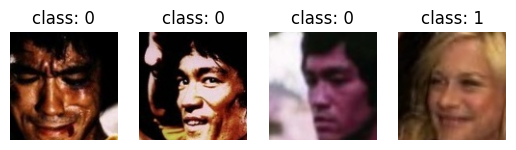

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.bool = bool  # ty:ignore[unresolved-attribute]

import mxnet as mx  # noqa: E402

data_iter = mx.image.ImageIter(
    batch_size=4,
    data_shape=(3, 112, 112),
    path_imgrec="./data/casia-webface/train.rec",
    path_imgidx="./data/casia-webface/train.idx",
    # path_imgrec="./data/ms1m-retinaface-t1/train.rec",
    # path_imgidx="./data/ms1m-retinaface-t1/train.idx",
    label_width=2,
)

data_iter.reset()

for _ in range(4):
    batch = data_iter.next()
    data = batch.data[0]
    label = batch.label[0].asnumpy()[:, 0]  # identity label

    for i in range(4):
        ax = plt.subplot(1, 4, i + 1)
        plt.imshow(data[i].asnumpy().astype(np.uint8).transpose((1, 2, 0)))
        ax.set_title(f"class: {int(label[i])}")
        plt.axis("off")

    plt.show()

### Code to show a single image


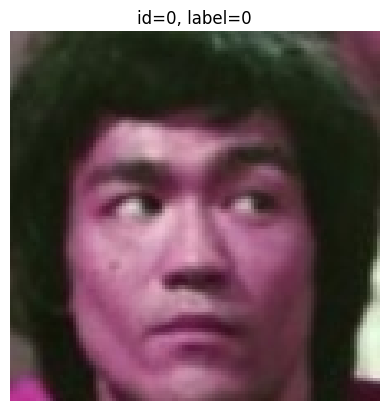

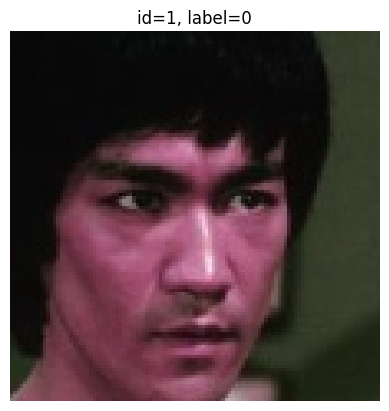

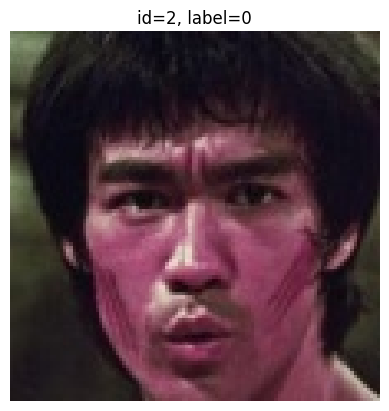

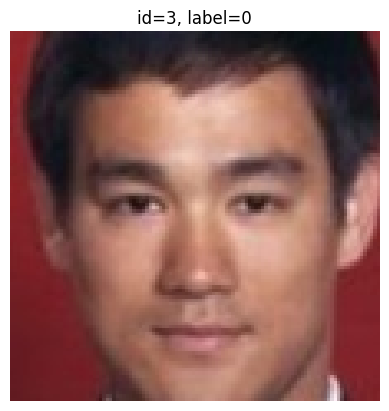

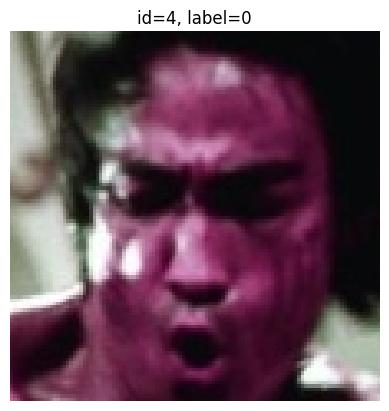

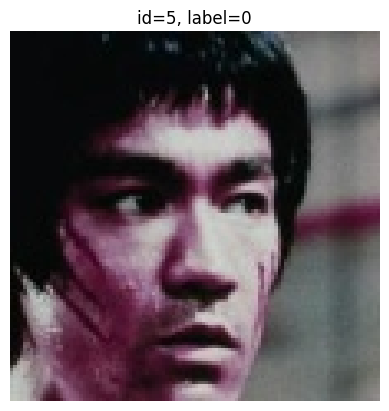

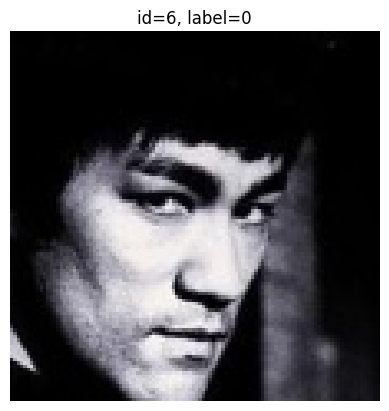

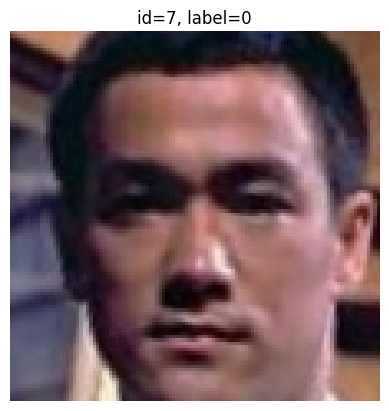

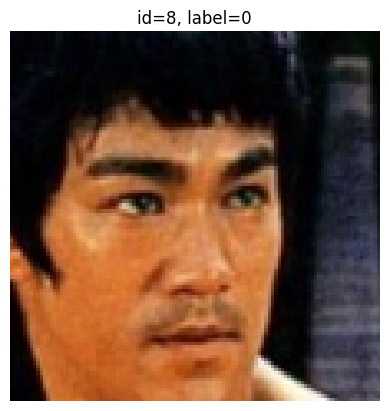

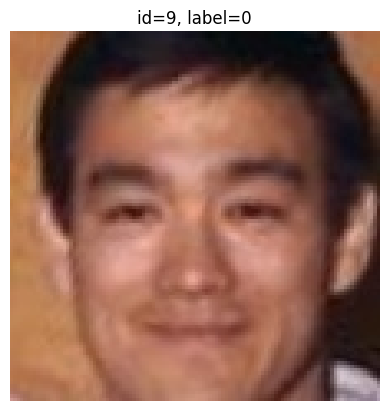

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.bool = bool  # ty:ignore[unresolved-attribute]

import mxnet as mx  # noqa: E402
from mxnet import recordio  # noqa: E402

path_imgrec = "./data/casia-webface/train.rec"
path_imgidx = "./data/casia-webface/train.idx"
# path_imgrec = "./data/ms1m-retinaface-t1/train.rec"
# path_imgidx = "./data/ms1m-retinaface-t1/train.idx"

imgrec = recordio.MXIndexedRecordIO(path_imgidx, path_imgrec, "r")

# %% 1 ~ 409623
# for i in range(409623):
for i in range(10):
    header, s = recordio.unpack(imgrec.read_idx(i + 1))
    img = mx.image.imdecode(s).asnumpy()

    label = header.label
    if not isinstance(label, (int, float)):
        label = label[0]
    label = int(label)

    plt.imshow(img)
    plt.title(f"id={i}, label={label}")
    plt.axis("off")
    plt.show()

## Command Line Interpretation

- **`CUDA_VISIBLE_DEVICES`** : Enter the GPU ID (`0`, `1`, `2`, `3`).

- **`-w` (`--workers_id`)** : Enter the Worker ID (`0`, `1`, `2`, `3`) [Same as GPU ID].

- **`-b` (`--batch_size`)** : Batch Size. Change according to GPU memory.

- **`-d` (`--data_mode`)** : Use which Database [`casia`, `casia`]

- **`-n` (`--net`)** : Which Network [`VIT`, `VITs`, `EffNet_V2_face`, `EffNet_V2_VIT`, `EffNet_V1_VIT`, `EffNet_trim_VIT`, `CROSSVIT`].

- **`--outdir` (Output Directory)** : Change the `output_dir` to the name of the dataset in the `./results/<network_name>_<output_dir>_cosface_sx`.


### ViT-P8S8


In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VIT -head CosFace --outdir ./results/ViT-P8S8_casia_cosface_s1 --warmup-epochs 1 --lr 3e-4

GPU_ID [0]
Overall Configurations:
{'SEED': 1337, 'INPUT_SIZE': [112, 112], 'EMBEDDING_SIZE': 512, 'GPU_ID': [0], 'DEVICE': device(type='cuda', index=0), 'MULTI_GPU': True, 'NUM_EPOCH': 125, 'BATCH_SIZE': 8, 'DATA_ROOT': './data/casia-webface/', 'EVAL_PATH': './eval/', 'BACKBONE_NAME': 'VIT', 'HEAD_NAME': 'CosFace', 'TARGET': ['lfw'], 'BACKBONE_RESUME_ROOT': '', 'WORK_PATH': './results/ViT-P8S8_casia_cosface_s1'}
./data/casia-webface/train.rec ./data/casia-webface/train.idx
header0 label [490624. 501196.]
id2range 10572
Number of Training Classes: 10572
./eval/lfw.bin
loading bin 0
loading bin 1000
loading bin 2000
loading bin 3000
loading bin 4000
loading bin 5000
loading bin 6000
loading bin 7000
loading bin 8000
loading bin 9000
loading bin 10000
loading bin 11000
torch.Size([12000, 3, 112, 112])
ver lfw
self.device_id [0]
self.device_id [0]
[INFO]: Loading pre-trained weights...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /home/debargha/.cac

In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VIT -head CosFace --outdir ./results/ViT-P8S8_casia_cosface_s2 --warmup-epochs 0 --lr 1e-4 -r <path_to_model>

In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VIT -head CosFace --outdir ./results/ViT-P8S8_casia_cosface_s3 --warmup-epochs 0 --lr 5e-5 -r <path_to_model>

### ViT-P12S8


In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VITs -head CosFace --outdir ./results/ViT-P12S8_casia_cosface_s1 --warmup-epochs 1 --lr 3e-4

In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VITs -head CosFace --outdir ./results/ViT-P12S8_casia_cosface_s2 --warmup-epochs 0 --lr 1e-4 -r <path_to_model>

In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n VITs -head CosFace --outdir ./results/ViT-P12S8_casia_cosface_s3 --warmup-epochs 0 --lr 5e-5 -r <path_to_model>

### EfficientNet


In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n EffNet_V2_face -head CosFace --outdir ./results/EffNet_V2_face_casia_cosface_s1 --warmup-epochs 0 --lr 3e-5

### EfficientNet + ViT


In [ ]:
!CUDA_VISIBLE_DEVICES='0' python3 -u train.py -b 8 -w 0 -d casia -n EffNet_trim_VIT -head CosFace --outdir ./results/EfficientNet_Trim_ViT_casia_cosface_s1 --warmup-epochs 0 --lr 3e-5